Setup and Load the data
1.1 Install dependencies
1.2 Remove dodgy images
1.3 Load Data


In [1]:
import tensorflow as tf
import os

In [2]:
# To set the limit so I dont get out of memory error,
# not letting it use all of the cpu or gpu
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)


# Remove Dodgy Images

In [3]:
import cv2
import imghdr

/var/folders/9n/16mvn3d930v3b5pg4w24rv9m0000gn/T/ipykernel_98601/4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [4]:
data_dir = 'Data'

In [5]:
image_exts = ['jpeg','jpg','bmp','png']

In [6]:
os.listdir(data_dir)

['test_sad.jpg',
 'happy',
 '.DS_Store',
 'sad',
 'very-happy-people.jpg',
 'test_happy.jpg',
 'saadgirl.jpg']

In [8]:
os.listdir(os.path.join(data_dir,'happy'))
# to get the list of photos in happy folder

['images26.jpg',
 'e162ccda8ce0f197f8863f327add9233.jpg',
 '05-12-21-happy-people.jpg',
 'GettyImages-871518740-1024x707.jpg',
 '7-principles-of-successful-and-happy-people.png',
 'how-happy-are-healthy-people.jpg',
 'physed-happiness-facebookJumbo.jpg',
 '170404-happy-workers-feature.jpg',
 'image18.jpeg',
 'MV5BMTM3ODM0NTQ1MF5BMl5BanBnXkFtZTcwMzAxMTM5OA._V1_.jpg',
 'images31.jpg',
 'Happy-people-raise-happy-kids-raise-yourself-first.jpg',
 'habits-that-define-very-happy-people.jpg',
 'goup-happy-people-group-jumping-isolated-white-background-35582232.jpg',
 '1902587.jpg',
 'o-HAPPY-facebook.jpg',
 '07-120104-happy_people_are_not_nice_people.jpg',
 'happy-people-13772392.jpg',
 'images30.jpg',
 'image15.jpeg',
 'young-and-happy-people-vector-15114154.jpg',
 'maxresdefault2.jpg',
 'bigstock-Portrait-Of-Smiling-Employees-272904928-min-scaled.jpg',
 'happy-people-1024x768.jpeg',
 '1902540.jpg',
 'hqdefault.jpg',
 'image19.jpeg',
 'images36.jpg',
 'images22.jpg',
 'tmp_6mv7xy_5d5b15258a50

In [10]:
# To improve the quality we can remove images of size less than 10 KB
import os

folders = ["Data/happy", "Data/sad"]
size_threshold = 10 * 1024   # 10 KB

deleted = 0

for folder in folders:
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)

        if os.path.isfile(file_path):
            size = os.path.getsize(file_path)

            if size < size_threshold:
                os.remove(file_path)
                print(f"Deleted: {file_path} ({size} bytes)")
                deleted += 1

print(f"\nTotal deleted files: {deleted}")

Deleted: Data/happy/image15.jpeg (10206 bytes)
Deleted: Data/happy/images22.jpg (10000 bytes)
Deleted: Data/happy/image27.jpeg (9961 bytes)
Deleted: Data/sad/image20.jpeg (9778 bytes)

Total deleted files: 4


In [19]:
for image_class in os.listdir(data_dir): # goes inside folder of data_dir = Data
        class_path = os.path.join(data_dir, image_class)
        # Skip files like .DS_Store
        if not os.path.isdir(class_path):
            continue
        for image in os.listdir(os.path.join(data_dir,image_class)):
        # it is data_dir = data and image class = happy and then next time sad
        # inside folder look for files with extensions of images
            image_path = os.path.join(data_dir, image_class, image)
            try:
                img = cv2.imread(image_path) # reading the particular image in the folder in numpy array type
                tip = imghdr.what(image_path)
                if tip not in image_exts:
                    print('Image not in ext list{}'.format(image_path))
                    os.remove(image_path)

            except Exception as e:
                print('Issue with image {}'.format(image_path))
            


.... ?? -> gives you documentation of that method

Load Data


In [39]:
import numpy as np
import matplotlib.pyplot as plt


In [25]:
data = tf.keras.utils.image_dataset_from_directory('Data')
# it will do the work for you like resizing and other preprocessing stuff

Found 166 files belonging to 2 classes.


In [26]:
data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [30]:
# we want to use this data so convert it into numpy iterator
data_iterator = data.as_numpy_iterator()
data_iterator # allowing us to access our data pipeline

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x30636b190>)

In [31]:
# now grabbing one batch 
batch = data_iterator.next()

In [32]:
batch

(array([[[[  3.       ,   9.011719 ,  12.035156 ],
          [  4.       ,  16.       ,  20.       ],
          [ 12.2890625,  64.15234  ,  80.55859  ],
          ...,
          [ 47.882812 , 236.9414   , 253.       ],
          [ 48.       , 238.       , 252.       ],
          [ 47.       , 239.       , 253.       ]],
 
         [[  5.0234375,  19.011719 ,  20.046875 ],
          [ 11.       ,  45.       ,  56.       ],
          [ 27.527344 , 130.63672  , 163.39844  ],
          ...,
          [ 46.941406 , 236.9414   , 253.       ],
          [ 47.       , 237.       , 253.       ],
          [ 47.       , 238.       , 253.       ]],
 
         [[ 22.011719 , 101.09375  , 127.10547  ],
          [ 29.       , 142.       , 177.       ],
          [ 33.117188 , 165.52734  , 207.70312  ],
          ...,
          [ 47.       , 234.       , 252.       ],
          [ 47.       , 234.       , 252.       ],
          [ 46.       , 235.       , 252.       ]],
 
         ...,
 
         [[ 

In [34]:
len(batch)
# 2 parts one is image representation and the other is label

2

In [ ]:
# images represented as numpy arrays
batch[0].shape
# batch size of 32  based on keras.utils.image.... we can change batch size
# keras utility automatically batches them in size - preprocessing
# 32 images of size 256 * 256 * 3

(32, 256, 256, 3)

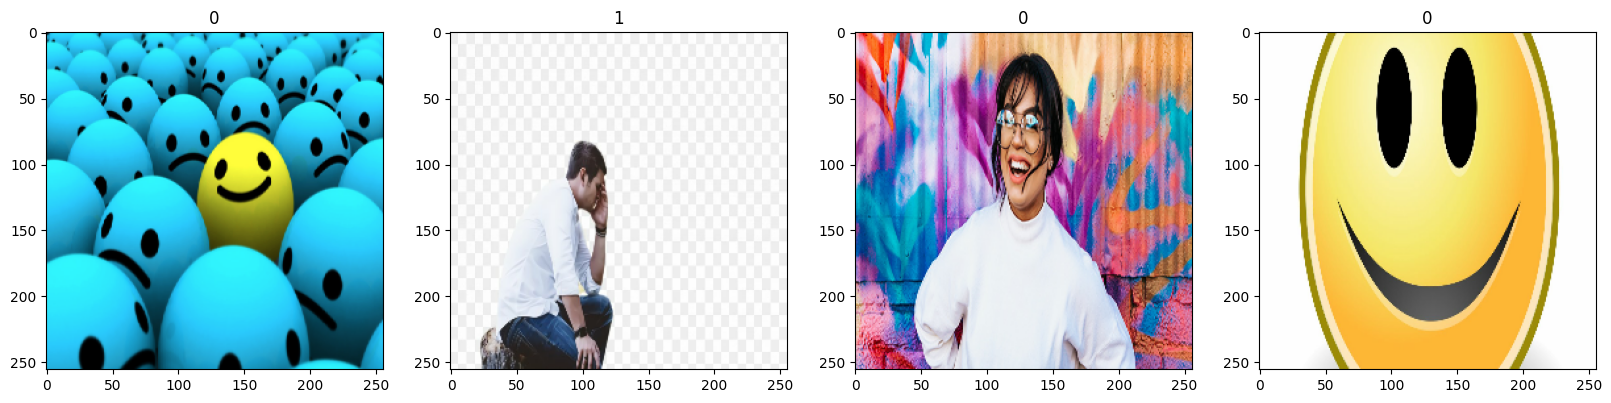

In [48]:
fig, ax = plt.subplots(ncols=4, figsize =(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx]) 

This shows 0 for happy and 1 for sad

# Preprocessing the Data

Scale the data

In [ ]:
# there is map function that allows us to use a particular type of transformation
#  as our data is preprocessed in data pipelinedata = data.map(lambda x ,y : (x/255 ,y ))

In [43]:
data.as_numpy_iterator().next() # our next batch

(array([[[[9.68627453e-01, 9.92156863e-01, 9.84313726e-01],
          [9.68627453e-01, 9.92156863e-01, 9.84313726e-01],
          [9.69975471e-01, 9.93504882e-01, 9.85661745e-01],
          ...,
          [9.92156863e-01, 9.92156863e-01, 9.92156863e-01],
          [9.92156863e-01, 9.92156863e-01, 9.92156863e-01],
          [9.92156863e-01, 9.92156863e-01, 9.92156863e-01]],
 
         [[9.68627453e-01, 9.92156863e-01, 9.84313726e-01],
          [9.68627453e-01, 9.92156863e-01, 9.84313726e-01],
          [9.67769623e-01, 9.91299033e-01, 9.83455896e-01],
          ...,
          [9.92156863e-01, 9.92156863e-01, 9.92156863e-01],
          [9.92156863e-01, 9.92156863e-01, 9.92156863e-01],
          [9.92156863e-01, 9.92156863e-01, 9.92156863e-01]],
 
         [[9.68627453e-01, 9.92156863e-01, 9.84313726e-01],
          [9.68627453e-01, 9.92156863e-01, 9.84313726e-01],
          [9.64705884e-01, 9.88235295e-01, 9.80392158e-01],
          ...,
          [9.92156863e-01, 9.92156863e-01, 9.9215

In [49]:
batch = data.as_numpy_iterator().next()

Split the data

In [51]:
len(data)

6

In [56]:
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)
test_size = int(len(data) * 0.1)+1


In [61]:
train_size + val_size + test_size

6

In [62]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [64]:
len(train) # length of train is 4 batches

4

Building the model

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [66]:
model = Sequential()


In [ ]:
# Adding a convulational layer and max pooling layer, input layer
# 16 filters of shape 3x3 and a stride of 1 pass through activation
model.add(Conv2D(16 , (3,3), 1, activation='relu', input_shape = (256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32 , (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16 , (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/opt/anaconda3/envs/imgenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.compile('adam',loss = tf.losses.BinaryCrossentropy(),metrics=['accuracy'])
# our loss is accuracy for now

In [70]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 252, 252, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,698,945 (14.11 MB)

 Trainable params: 3,698,945 (14.11 MB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [71]:
logdir = 'logs'

In [72]:
tensorflow_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)


In [74]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorflow_callback])


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.8359 - loss: 0.3981 - val_accuracy: 0.7188 - val_loss: 0.5289
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.8594 - loss: 0.3642 - val_accuracy: 0.8125 - val_loss: 0.3633
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.8359 - loss: 0.3735 - val_accuracy: 0.9062 - val_loss: 0.2566
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - accuracy: 0.8281 - loss: 0.3617 - val_accuracy: 0.8125 - val_loss: 0.3574
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 0.8594 - loss: 0.3050 - val_accuracy: 0.9062 - val_loss: 0.2647
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.8516 - loss: 0.3086 - val_accuracy: 0.9062 - val_loss: 0.2390
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.8906 - loss: 0.2381 - val_accuracy: 0.8438 - val_loss: 0.3253
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 0.8281 - loss: 0.3622 - val_accuracy: 0.9375 - val_loss:

Plot the Performance

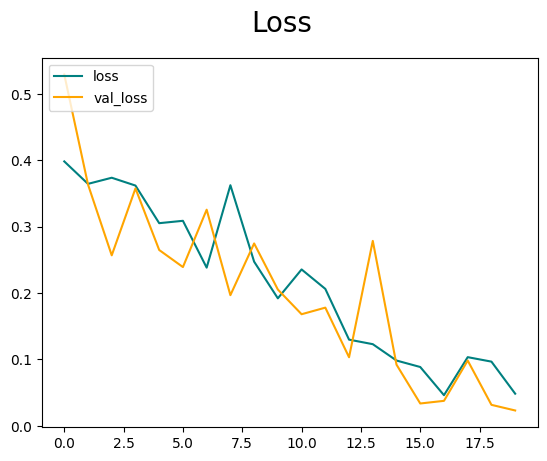

In [75]:
fig = plt.figure()
plt.plot(hist.history['loss'],color = 'teal', label='loss')
plt.plot(hist.history['val_loss'],color = 'orange', label='val_loss')
fig.suptitle('Loss',fontsize=20)
plt.legend(loc = "upper left")
plt.show()



if loss is going down and validation loss rising up, it means the model might be overfitting then use Regularization

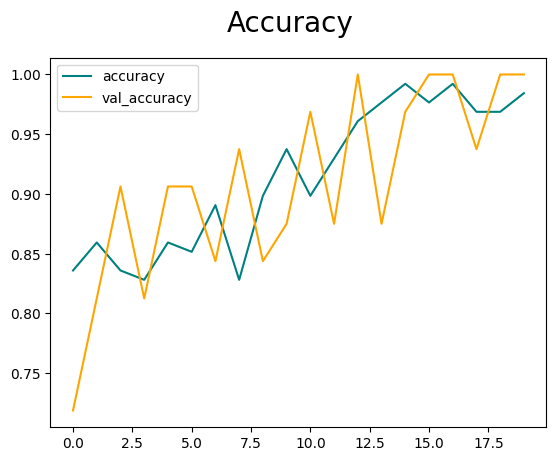

In [76]:
fig = plt.figure()
plt.plot(hist.history['accuracy'],color = 'teal', label='accuracy')
plt.plot(hist.history['val_accuracy'],color = 'orange', label='val_accuracy')
fig.suptitle('Accuracy',fontsize=20)
plt.legend(loc = "upper left")
plt.show()

# Evaluate Performance

In [77]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [78]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [83]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y,yhat)
    re.update_state(y,yhat)
    acc.update_state(y,yhat) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


2026-03-18 15:06:57.693859: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [84]:
print(f'Precision:{pre.result().numpy},Recall: {re.result().numpy},Accuracy: {acc.result().numpy}')

Precision:<bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(), dtype=float32, numpy=1.0>>,Recall: <bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(), dtype=float32, numpy=1.0>>,Accuracy: <bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(), dtype=float32, numpy=1.0>>


Testing The Model

In [85]:
import cv2

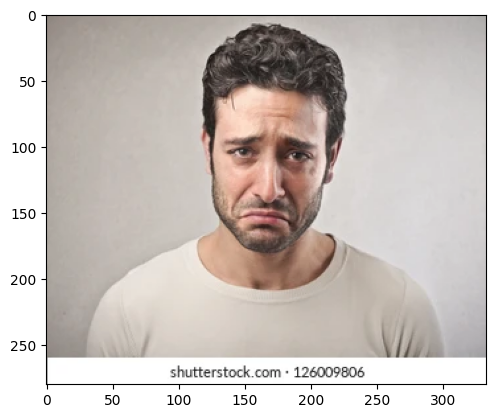

In [99]:
img = cv2.imread('sad_test.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

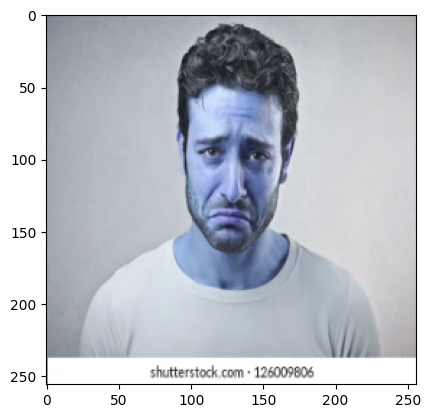

In [100]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [101]:
resize.shape

TensorShape([256, 256, 3])

In [92]:
np.expand_dims(resize,0).shape

(1, 256, 256, 3)

In [102]:
yhat = model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [96]:
yhat # it is 0 bcoz of sigmoid and happy person is 0, as in our model

array([[0.23444502]], dtype=float32)

In [103]:
if yhat < 0.5:
    print(f'Predicted class is Happy')
else:
    print(f'Predicted Class is Sad')

Predicted Class is Sad


# Saving the model

In [104]:
from tensorflow.keras.models import load_model


In [105]:
model.save(os.path.join('models','happysadmodel.h5'))
